# 02 · A synthetic-data tour

petekTools ships a family of **seeded, believable synthetic-data generators** —
for tests, demos, tutorials and benchmarks, with no real dataset anywhere. This
notebook stitches them into one small, coherent make-believe asset:

1. a structural **dome** + a **thickness** map + a depositional **trend**,
2. a **closure outline** and a **study-area** frame,
3. **wells** placed inside the closure, with picked **tops**,
4. a directional **well trajectory**,
5. coupled **petrophysical** curves (facies -> porosity, and a zoned log).

Everything is seeded and reproduces bit-for-bit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import petektools as pt
print("petektools", pt.__version__)

INC = 50.0
def as_map(field):
    return np.asarray(field, dtype=float).T

def show_map(ax, field, lat, title, cmap="viridis", **kw):
    im = ax.imshow(as_map(field), origin="lower",
                   extent=[0, lat.ncol*INC, 0, lat.nrow*INC],
                   aspect="equal", cmap=cmap, **kw)
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    return im

petektools 0.2.0


## 1 · Structure, thickness, trend

Three correlated-field generators on a shared lattice:

- `synth_dome_surface` — an elliptical four-way closure (crest = max) with tilt
  and correlated noise;
- `synth_isochore` — a thickness map about a mean, clamped at zero;
- `synth_trend_map` — a `[0, 1]` depositional trend, here built to correlate
  with the structure.

In [2]:
lat = pt.Lattice(0.0, 0.0, INC, INC, 48, 38)

noise_vg = pt.Variogram("spherical", 0.0, 1.0, 600.0)
dome = pt.synth_dome_surface(lat, relief=95.0, aspect=1.7, tilt=5.0,
                             noise_variance=12.0, noise_variogram=noise_vg, seed=7)

iso_vg = pt.Variogram("exponential", 0.0, 1.0, 700.0)
iso = pt.synth_isochore(lat, mean_thickness=42.0, variability=7.0,
                        variogram=iso_vg, seed=9)

trend_vg = pt.Variogram("spherical", 0.0, 1.0, 800.0)
trend = pt.synth_trend_map(lat, trend_vg, seed=5, correlate_with=(dome, 0.7))

print(f"dome crest {np.max(dome):.1f}, iso mean {np.mean(iso):.1f} m, "
      f"trend {np.min(trend):.2f}..{np.max(trend):.2f}")

dome crest 97.0, iso mean 43.0 m, trend 0.00..1.00


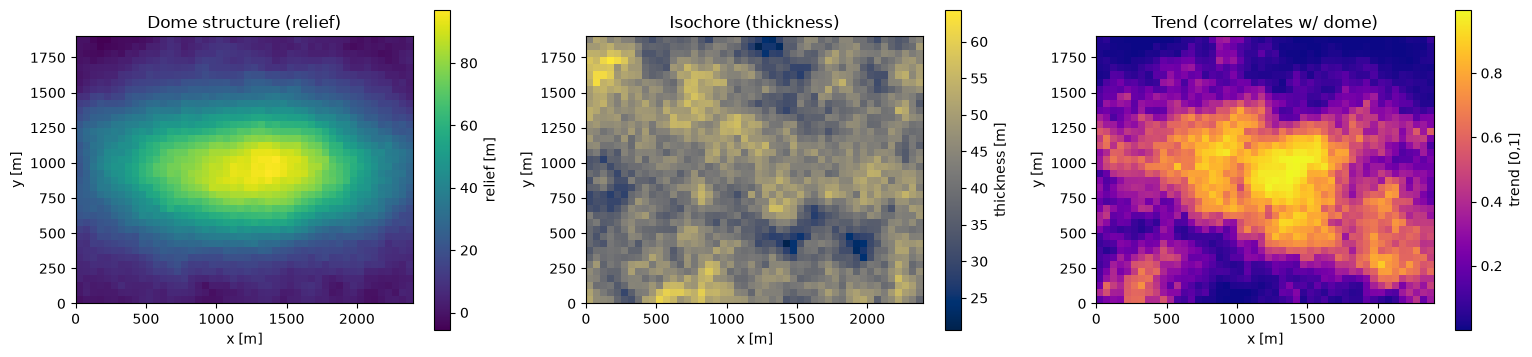

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
fig.colorbar(show_map(axes[0], dome, lat, "Dome structure (relief)"),
             ax=axes[0], shrink=0.8, label="relief [m]")
fig.colorbar(show_map(axes[1], iso, lat, "Isochore (thickness)", cmap="cividis"),
             ax=axes[1], shrink=0.8, label="thickness [m]")
fig.colorbar(show_map(axes[2], trend, lat, "Trend (correlates w/ dome)", cmap="plasma"),
             ax=axes[2], shrink=0.8, label="trend [0,1]")
plt.tight_layout(); plt.show()

## 2 · Closure outline & study-area frame

`closure_outline(surface, lattice, spill_depth)` returns the largest closed
contour of the structure at a spill level (marching squares) — the map footprint
of the four-way closure. `study_area_outline` gives a rounded-rectangle extent to
frame the asset.

In [4]:
spill = float(np.max(dome)) - 55.0   # a level that closes below the crest
closure = pt.closure_outline(dome, lat, spill)
frame = pt.study_area_outline(0.0, 0.0, lat.ncol*INC, lat.nrow*INC,
                              corner_radius=180.0, arc_steps=6)
print(f"closure ring: {len(closure)} vertices at spill {spill:.1f}")

closure ring: 118 vertices at spill 42.0


## 3 · Wells inside the closure, and their tops

`place_wells_in_polygon` scatters seeded well heads inside the closure by
rejection sampling. `tops_from_surface` then picks a top from the structure at
each well, adding one residual draw per well (here a small uniform mis-tie).

In [5]:
well_xy = pt.place_wells_in_polygon(closure, n=9, seed=3)
residual = pt.Sampler.uniform(-6.0, 6.0)
tops = pt.tops_from_surface(dome, lat, well_xy, residual, seed=4)
for k, ((x, y), t) in enumerate(zip(well_xy, tops), start=1):
    print(f"  W{k:02d}  x={x:7.1f}  y={y:7.1f}  top={t:6.1f}")

  W01  x=  359.4  y=  792.2  top=  46.3
  W02  x=  535.6  y=  860.8  top=  66.3
  W03  x=  648.3  y=  840.3  top=  71.8
  W04  x=  876.3  y= 1060.9  top=  79.0
  W05  x= 1125.2  y= 1357.2  top=  46.6
  W06  x= 1207.5  y=  970.8  top=  97.6
  W07  x=  481.9  y= 1033.1  top=  61.7
  W08  x= 1667.7  y= 1113.3  top=  70.8
  W09  x= 1966.0  y=  763.7  top=  48.4


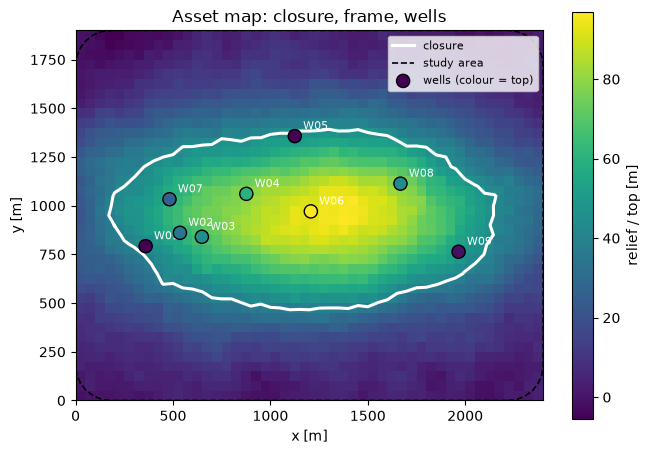

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 5.2))
im = show_map(ax, dome, lat, "Asset map: closure, frame, wells")
cx, cy = zip(*closure); ax.plot(list(cx)+[cx[0]], list(cy)+[cy[0]],
                                color="white", lw=2.2, label="closure")
fx, fy = zip(*frame); ax.plot(list(fx)+[fx[0]], list(fy)+[fy[0]],
                              color="k", lw=1.2, ls="--", label="study area")
wx, wy = zip(*well_xy)
ax.scatter(wx, wy, c=tops, cmap="viridis", edgecolor="k", s=90, zorder=4,
           label="wells (colour = top)")
for k, (x, y) in enumerate(well_xy, start=1):
    ax.annotate(f"W{k:02d}", (x, y), textcoords="offset points", xytext=(6, 5),
                fontsize=8, color="white")
fig.colorbar(im, ax=ax, shrink=0.85, label="relief / top [m]")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

## 4 · A directional well trajectory

`synth_trajectory_profile` synthesizes a deviated well by the minimum-curvature
relation. We drill a **build-and-hold** well from the first well head: vertical to
a kickoff, build to 42 deg inclination, then hold on a 90 deg azimuth. It returns
a columnar dict (`md`, `x`, `y`, `z`, `tvd`, `incl`, `azim`).

In [7]:
head = list(well_xy[0])
traj = pt.synth_trajectory_profile(head, kb_elevation=25.0, td=2600.0,
                                   md_step=30.0, seed=1, profile="build_hold",
                                   kickoff_md=850.0, build_rate_deg_per_30m=3.0,
                                   hold_incl_deg=42.0, azimuth_deg=90.0)
dls = pt.max_dogleg_severity(traj["md"], traj["incl"], traj["azim"])
print(f"{len(traj['md'])} stations, max inclination {max(traj['incl']):.1f} deg, "
      f"max dogleg {dls:.2f} deg/30m")

88 stations, max inclination 42.0 deg, max dogleg 3.00 deg/30m


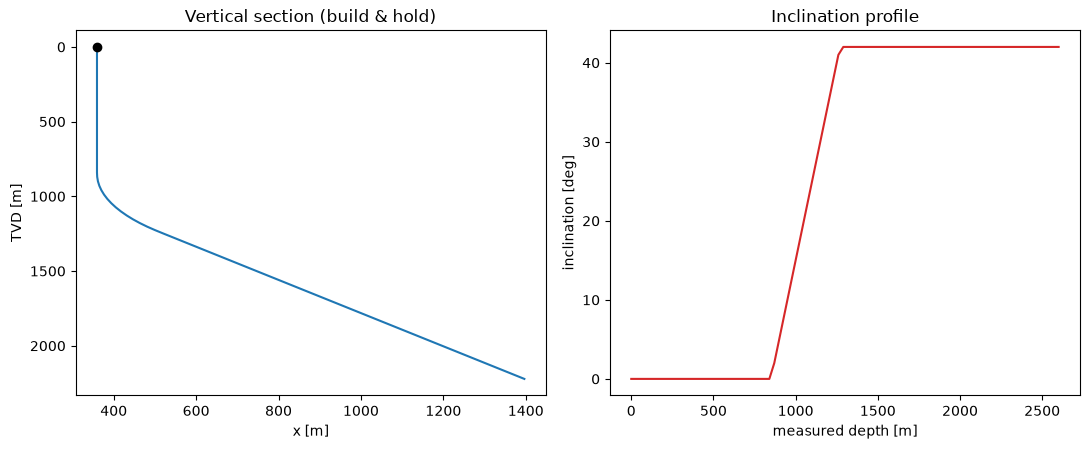

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
axes[0].plot(traj["x"], traj["tvd"], color="#1f77b4")
axes[0].scatter([traj["x"][0]], [traj["tvd"][0]], color="k", zorder=3)
axes[0].invert_yaxis(); axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("TVD [m]")
axes[0].set_title("Vertical section (build & hold)")
axes[1].plot(traj["md"], traj["incl"], color="#d62728")
axes[1].set_xlabel("measured depth [m]"); axes[1].set_ylabel("inclination [deg]")
axes[1].set_title("Inclination profile")
plt.tight_layout(); plt.show()

## 5 · Coupled petrophysical curves

Two complementary generators of believable, depth-correlated properties:

- `synth_facies_series` -> a binary sand/shale log; `synth_por_with_facies`
  paints porosity onto it (sand and shale draw from different `{mean, std}`
  targets over a shared AR(1) driver);
- `synth_log_series` -> one continuous, zoned, depth-autocorrelated log over a
  `ZoneSpec` stack (each zone hits its `{mean, std}`, with blended transitions).

In [9]:
STEP = 0.15  # m sampling
facies_b = pt.synth_facies_series(n=520, depth_step=STEP, ntg_target=0.55,
                                  bed_scale_m=3.0, seed=2)     # packed bytes, 1=sand/0=shale
por = pt.synth_por_with_facies(facies_b, depth_step=STEP,
                               sand_mean=0.24, sand_std=0.03,
                               shale_mean=0.06, shale_std=0.02,
                               corr_length_m=2.0, seed=2)      # aligned porosity list
facies = np.frombuffer(facies_b, dtype=np.uint8)
por = np.asarray(por, dtype=float)
depth = np.arange(len(facies)) * STEP
print(f"net-to-gross {facies.mean():.2f}, sand phi {por[facies==1].mean():.3f}, "
      f"shale phi {por[facies==0].mean():.3f}")

net-to-gross 0.47, sand phi 0.246, shale phi 0.059


In [10]:
zones = [pt.ZoneSpec(30.0, 0.28, 0.04, 2.5),   # (thickness_m, mean, std, corr_len_m)
         pt.ZoneSpec(22.0, 0.14, 0.05, 1.5),
         pt.ZoneSpec(34.0, 0.30, 0.03, 2.5)]
zlog = np.array(pt.synth_log_series(zones, depth_step=STEP, transition_beds=3, seed=7))
zdepth = np.arange(len(zlog)) * STEP
counts = pt.zone_sample_counts(zones, STEP)
print("zone sample layout:", counts, "-> total", sum(counts), "==", len(zlog))

zone sample layout: [200, 147, 227] -> total 574 == 574


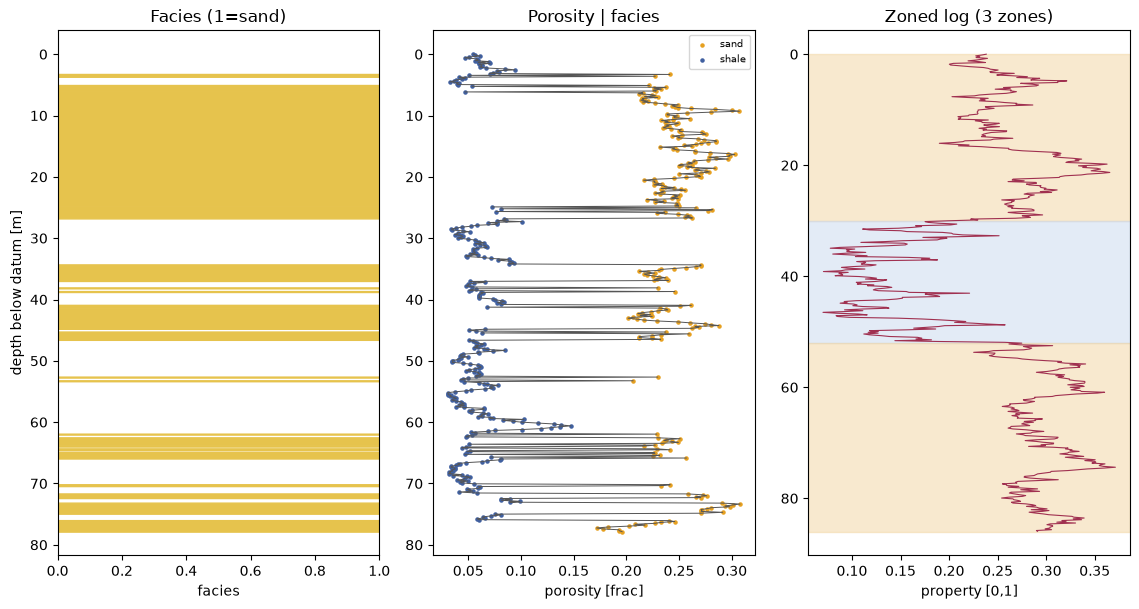

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 6.2), sharey=False)
# facies track
axes[0].fill_betweenx(depth, 0, facies, step="mid", color="#e6c34d", label="sand")
axes[0].set_xlim(0, 1); axes[0].invert_yaxis()
axes[0].set_xlabel("facies"); axes[0].set_ylabel("depth below datum [m]")
axes[0].set_title("Facies (1=sand)")
# porosity track, coloured by facies
axes[1].plot(por, depth, color="#555", lw=0.7)
axes[1].scatter(por[facies==1], depth[facies==1], s=5, color="#e6a020", label="sand")
axes[1].scatter(por[facies==0], depth[facies==0], s=5, color="#4060a0", label="shale")
axes[1].invert_yaxis(); axes[1].set_xlabel("porosity [frac]")
axes[1].set_title("Porosity | facies"); axes[1].legend(fontsize=7)
# zoned log
b = 0.0
for z, c in zip(zones, ["#f2d5a0", "#c9d8ef", "#f2d5a0"]):
    axes[2].axhspan(b, b + z.thickness_m, color=c, alpha=0.5); b += z.thickness_m
axes[2].plot(zlog, zdepth, color="#a03050", lw=0.8)
axes[2].invert_yaxis(); axes[2].set_xlabel("property [0,1]")
axes[2].set_title("Zoned log (3 zones)")
plt.tight_layout(); plt.show()

### Recap

From a handful of seeded calls we built a complete synthetic asset:

- **maps** — `synth_dome_surface`, `synth_isochore`, `synth_trend_map`;
- **geometry** — `closure_outline`, `study_area_outline`, `place_wells_in_polygon`,
  `tops_from_surface`;
- **a trajectory** — `synth_trajectory_profile` (+ `max_dogleg_severity`);
- **petrophysics** — `synth_facies_series` -> `synth_por_with_facies`, and a zoned
  `synth_log_series`.

Every generator is seeded and reproducible — ideal for tests, docs, and
benchmarks that must never touch a real dataset.